# 12 — Summary: Does CG Predict Financial Outcomes?

Pulls together the three empirical layers built on top of the CG index
(`06_index_calculation.ipynb` / `07_index_validation.ipynb`):

1. **Measurement** — index construction and validation (`06`, `07`)
2. **Event study** — short-window CARs around CG filing dates (`10_event_study.ipynb`)
3. **Portfolio sort** — CG-quintile long-short vs. FF5+MOM (`11_portfolios.ipynb`)
4. **Panel** — pooled `CG_t -> outcome_{t+1}` regressions (`09_regression.ipynb`)

Each layer applies its own Romano-Wolf step-down correction within its own test family
(event study: 30 tests, 6 sub-indices x 5 windows; portfolios: 6 tests, one per
sub-index's long-short alpha; panel: 42 tests, 6 sub-indices x 7 outcomes). The composite
is reported throughout as a summary line, not as a tested hypothesis on equal footing with
the six sub-indices — consistent with `07`'s finding that PC1 explains only ~21% of
variance with mixed-sign loadings, i.e. there is no dominant latent "governance quality"
factor to justify treating the composite as a single construct under correction.

This notebook does not re-run any estimation — it loads the CSVs each upstream notebook
already saved to `data/processed/` and reports them side by side.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path.cwd()
PROC = BASE / 'data' / 'processed'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid')

CG_CATS = ['AINDEX', 'BINDEX', 'CINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']


def sig_stars(p):
    if pd.isna(p): return ''
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''


# Event study
es_reg = pd.read_csv(PROC / 'event_study_regressions_primary.csv')
es_excl = pd.read_csv(PROC / 'event_study_regressions_excl_overlap.csv')
es_mean = pd.read_csv(PROC / 'event_study_mean_car_tests.csv')

# Portfolios
pf_reg = pd.read_csv(PROC / 'portfolio_factor_regressions.csv')
pf_rw = pd.read_csv(PROC / 'portfolio_longshort_romano_wolf.csv')
pf_turn = pd.read_csv(PROC / 'portfolio_turnover.csv')
pf_tc = pd.read_csv(PROC / 'portfolio_transaction_cost_sensitivity.csv')

# Panel
pn_ind = pd.read_csv(PROC / 'panel_individual_regressions.csv')
pn_rw = pd.read_csv(PROC / 'panel_romano_wolf.csv')
pn_comp = pd.read_csv(PROC / 'panel_composite_regressions.csv')

print('Event study   :', es_reg.shape, '| mean-CAR tests:', es_mean.shape)
print('Portfolios    :', pf_reg.shape, '| RW:', pf_rw.shape)
print('Panel         :', pn_ind.shape, '| RW:', pn_rw.shape, '| composite:', pn_comp.shape)

Event study   : (30, 10) | mean-CAR tests: (5, 7)
Portfolios    : (49, 9) | RW: (6, 4)
Panel         : (42, 8) | RW: (42, 5) | composite: (7, 6)


## 1 — Measurement layer (`06`, `07`)

Not re-run here — figures below are cited from `07_index_validation.ipynb`'s actual
executed output this session.

| Check | Result |
|---|---|
| Sub-indices | AINDEX, BINDEX, CINDEX, DINDEX, OINDEX, TRINDEX — CINDEX fully NLP-scored, the other five rule-based (DINDEX has 4 NLP-scored quality items) |
| Cronbach's α (complete-case) | AINDEX −0.19 (poor), BINDEX 0.31 (poor), DINDEX 0.68 (weak), OINDEX −0.08 (poor), TRINDEX 0.08 (poor), CINDEX 0.65 (weak) |
| Max VIF among sub-indices | 1.10 (near-zero multicollinearity) |
| PCA (diagnostic only, no composite stored) | PC1 explains ~21% of variance (barely above the 16.7% floor for 6 uncorrelated variables); mixed-sign loadings |
| Weighting-scheme sensitivity | min Spearman r = 0.90 (SEBI-weighted vs. equal-weighted) |
| Drop-ID sensitivity | min Spearman r = 0.96 (excl. vs incl. dropped metrics) |
| `DROP_IDS` (out-of-sample, FY23-only) | B7, TR1, TR2, TR4, O4 (data quality) + B14 (hard break) + B13 (FY23 return-association, t=−2.52) |
| External benchmark | none available (`data/raw/` has no NSE Prime or equivalent list) — documented gap, not filled with a proxy |

**Conclusion carried into every downstream layer**: the six sub-indices are close to
orthogonal, weak-to-poor on classical reliability, and have no dominant common factor.
They are treated as six separate, substantively distinct measures — not six noisy
readings of one "governance quality" — which is exactly why the composite is reported as
a summary line rather than the primary object of inference below.

## 2 — Event study layer (`10`)

2,426 filing events, 230 firms, Jul 2023 – Mar 2026. Mean CAR is significantly negative in
4 of 5 windows (unconditional drift around CG filings, unrelated to CG score). Of the 30
(sub-index × window) cross-sectional regression tests, only 1 clears raw p<.10 and it does
not survive Romano-Wolf; the overlap-excluded robustness clears 0/30.

In [2]:
print('Mean CAR (unconditional, all firms):')
print(es_mean[['Window', 'N', 'Mean_CAR', 't_stat', 'p_t', 'BMP_z', 'p_bmp']].round(4).to_string(index=False))

print(f"\nCross-sectional regression (CAR ~ CG_score + controls), primary: "
      f"{(es_reg['p_rw'] < 0.10).sum()} / {len(es_reg)} survive RW p<.10")
print(es_reg[es_reg['p_rw'] < 0.10][['Category', 'Window', 'beta', 't', 'p_raw', 'p_rw']].round(4).to_string(index=False))

print(f"\nOverlap-excluded robustness: {(es_excl['p_rw'] < 0.10).sum()} / {len(es_excl)} survive RW p<.10")

Mean CAR (unconditional, all firms):
Window    N  Mean_CAR  t_stat    p_t   BMP_z  p_bmp
  m1p1 2426   -0.0045 -5.3704 0.0000 -5.2954 0.0000
  m3p3 2426   -0.0087 -6.1382 0.0000 -6.1955 0.0000
  m5p5 2426   -0.0081 -4.3516 0.0000 -4.4873 0.0000
m10p10 2426   -0.0005 -0.1516 0.8795 -0.0629 0.9498
   0p5 2426   -0.0057 -4.4273 0.0000 -4.5355 0.0000

Cross-sectional regression (CAR ~ CG_score + controls), primary: 1 / 30 survive RW p<.10
Category Window   beta      t  p_raw  p_rw
  CINDEX   m1p1 0.0138 2.2648 0.0235 0.094

Overlap-excluded robustness: 0 / 30 survive RW p<.10


## 3 — Portfolio layer (`11`)

Quintile sorts, 3 formation years (2023-2025), 34 pooled months. Long-short alpha is
negative for 5 of 6 sub-indices and the composite; 0 of 6 sub-indices survive Romano-Wolf.
Transaction costs (30bps/rebalance) add a small additional drag.

In [3]:
ls_alpha = pf_reg[pf_reg['Portfolio'] == 'LS'][['Family', 'N_months', 'ann_alpha', 't_alpha', 'Sharpe', 'IR']]
ls_alpha = ls_alpha.merge(pf_rw.rename(columns={'Category': 'Family'})[['Family', 'p_rw']], on='Family', how='left')
print('Long-short alpha by CG measure (COMPOSITE = reference, not RW-tested):')
print(ls_alpha.round(4).to_string(index=False))

print(f"\nSurvive RW p<.10 (6 sub-indices only): {(pf_rw['p_rw'] < 0.10).sum()} / {len(pf_rw)}")

print('\nTransaction-cost sensitivity (long-short alpha):')
print(pf_tc[['Family', 'alpha_pre_tc', 'alpha_post_tc', 'tc_drag_annualised']].round(4).to_string(index=False))

Long-short alpha by CG measure (COMPOSITE = reference, not RW-tested):
   Family  N_months  ann_alpha  t_alpha  Sharpe      IR   p_rw
COMPOSITE        34    -0.1646  -1.7479 -0.8336 -1.2803    NaN
   AINDEX        34    -0.0996  -1.3499 -0.3874 -0.9888 0.8135
   BINDEX        34    -0.0101  -0.1403 -0.1259 -0.1028 0.9930
   CINDEX        34    -0.1168  -1.3468 -0.7557 -0.9865 0.8135
   DINDEX        34    -0.1506  -1.6034 -0.6408 -1.1745 0.7430
   OINDEX        34     0.0013   0.0191 -0.0028  0.0140 0.9960
  TRINDEX        34    -0.0852  -1.1259 -1.1692 -0.8247 0.8135

Survive RW p<.10 (6 sub-indices only): 0 / 6

Transaction-cost sensitivity (long-short alpha):
   Family  alpha_pre_tc  alpha_post_tc  tc_drag_annualised
COMPOSITE       -0.1646        -0.1673              0.0027
   AINDEX       -0.0996        -0.1023              0.0027
   BINDEX       -0.0101        -0.0128              0.0027
   CINDEX       -0.1168        -0.1195              0.0027
   DINDEX       -0.1506        -0.

## 4 — Panel layer (`09`)

`CG_t -> outcome_{t+1}`, T=2 (FY23, FY24), 466 firm-FY observations, 233 firms (fully
balanced). 0 of 42 (sub-index × outcome) tests survive Romano-Wolf. The closest
(BINDEX → ff5_alpha_{t+1}) sits right at the boundary — see the instability note in
§6. The composite regression (summary spec, not RW-tested) is significantly negative on
all three volatility measures.

In [4]:
print(f"Survive RW p<.10 (42 sub-index x outcome tests): {(pn_rw['p_rw'] < 0.10).sum()} / {len(pn_rw)}")
print(pn_rw[pn_rw['p_rw'] < 0.10].round(4).to_string(index=False))

print('\nComposite regression (summary specification, not RW-tested):')
comp_show = pn_comp.copy()
comp_show['sig'] = comp_show['p'].apply(sig_stars)
print(comp_show.round(4).to_string(index=False))

Survive RW p<.10 (42 sub-index x outcome tests): 0 / 42
Empty DataFrame
Columns: [Category, Outcome, t, p_rw, sig_rw]
Index: []

Composite regression (summary specification, not RW-tested):
     Outcome   N    beta     se       t      p sig
     mar_pct 461 -0.0107 0.0223 -0.4819 0.6304    
  capm_alpha 461 -0.0128 0.0200 -0.6372 0.5246    
   ff5_alpha 461  0.0163 0.0282  0.5765 0.5649    
   total_vol 461 -0.0009 0.0003 -2.8716 0.0045 ***
    idio_vol 461 -0.0009 0.0003 -2.8919 0.0042 ***
downside_vol 461 -0.0004 0.0002 -2.5304 0.0121  **
         roe 460  0.0062 0.0083  0.7457 0.4566    


## 5 — Headline table

For each sub-index and the composite: event-study CAR(0,+5) sensitivity to CG score,
portfolio long-short alpha, and panel β on `ff5_alpha_{t+1}`. All Romano-Wolf adjusted
within their own layer's test family. **COMPOSITE has no event-study entry** — Task 4's
cross-sectional regressions were specified for the six sub-indices only, never built for
the composite, so there is nothing to report there rather than a blank filled in after the
fact. COMPOSITE's portfolio and panel entries are summary specifications, not part of
either layer's corrected family, and are marked accordingly rather than given a misleading
p_rw.

In [5]:
ROWS = CG_CATS + ['COMPOSITE']
headline = pd.DataFrame({'Category': ROWS}).set_index('Category')

# Event-study CAR(0,+5): six sub-indices only, no COMPOSITE spec exists
es_05 = es_reg[es_reg['Window'] == '0p5'].set_index('Category')
headline['event_car_beta'] = es_05['beta'].reindex(ROWS)
headline['event_car_p_rw'] = es_05['p_rw'].reindex(ROWS)

# Portfolio long-short alpha: all 7 rows have an alpha; p_rw only for the 6 sub-indices
pf_ls = pf_reg[pf_reg['Portfolio'] == 'LS'].set_index('Family')
headline['portfolio_ls_alpha'] = pf_ls['ann_alpha'].reindex(ROWS)
pf_rw_idx = pf_rw.set_index('Category')['p_rw']
headline['portfolio_ls_p_rw'] = pf_rw_idx.reindex(ROWS)

# Panel beta on ff5_alpha_t+1: six sub-indices from panel_individual_regressions,
# COMPOSITE from the separate (not RW-tested) composite regression
pn_ff5 = pn_ind[pn_ind['Outcome'] == 'ff5_alpha'].set_index('Category')
headline.loc[CG_CATS, 'panel_beta'] = pn_ff5['beta'].reindex(CG_CATS)
headline.loc[CG_CATS, 'panel_p_rw'] = pn_ff5['p_rw'].reindex(CG_CATS)
comp_ff5 = pn_comp[pn_comp['Outcome'] == 'ff5_alpha'].iloc[0]
headline.loc['COMPOSITE', 'panel_beta'] = comp_ff5['beta']
headline.loc['COMPOSITE', 'panel_p_rw'] = np.nan  # not part of the 42-test RW family

headline = headline.reset_index()
for col_beta, col_p, col_sig in [('event_car_beta', 'event_car_p_rw', 'event_sig'),
                                  ('portfolio_ls_alpha', 'portfolio_ls_p_rw', 'portfolio_sig'),
                                  ('panel_beta', 'panel_p_rw', 'panel_sig')]:
    headline[col_sig] = headline[col_p].apply(sig_stars)

print(headline.round(4).to_string(index=False))
headline.to_csv(PROC / 'headline_summary.csv', index=False)
print('\nSaved -> data/processed/headline_summary.csv')
print("Blank p_rw = not part of that layer's corrected test family (composite entries, and\n"
      "COMPOSITE's non-existent event-study spec).")

 Category  event_car_beta  event_car_p_rw  portfolio_ls_alpha  portfolio_ls_p_rw  panel_beta  panel_p_rw event_sig portfolio_sig panel_sig
   AINDEX          0.0058          1.0000             -0.0996             0.8135     -0.0328      0.9825                                  
   BINDEX         -0.0022          1.0000             -0.0101             0.9930      0.0989      0.1090                                  
   CINDEX          0.0087          0.9795             -0.1168             0.8135     -0.0561      0.6865                                  
   DINDEX         -0.0063          0.8435             -0.1506             0.7430     -0.0642      0.8255                                  
   OINDEX         -0.0030          1.0000              0.0013             0.9960     -0.0227      0.9900                                  
  TRINDEX         -0.0087          0.8480             -0.0852             0.8135      0.0314      0.9825                                  
COMPOSITE             NaN  

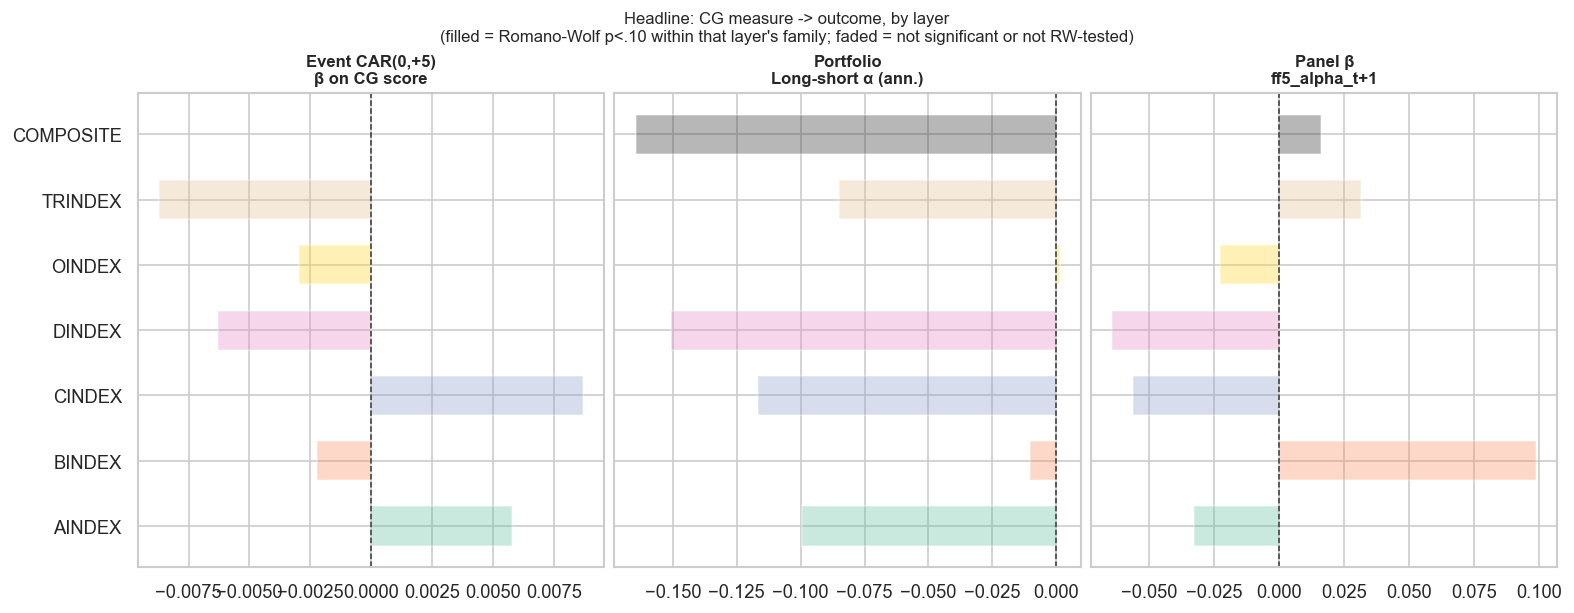

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True, constrained_layout=True)
specs = [('event_car_beta', 'event_car_p_rw', 'Event CAR(0,+5)\nβ on CG score'),
         ('portfolio_ls_alpha', 'portfolio_ls_p_rw', 'Portfolio\nLong-short α (ann.)'),
         ('panel_beta', 'panel_p_rw', 'Panel β\nff5_alpha_t+1')]
ypos = np.arange(len(ROWS))
colors = list(plt.cm.Set2(np.linspace(0, 0.8, len(CG_CATS)))) + ['#333333']

for ax, (col, pcol, title) in zip(axes, specs):
    for i, (cat, color) in enumerate(zip(ROWS, colors)):
        row = headline[headline['Category'] == cat].iloc[0]
        val = row[col]
        if pd.isna(val):
            continue
        p_rw = row[pcol]
        alpha_val = 0.9 if (pd.notna(p_rw) and p_rw < 0.10) else 0.35
        ax.barh(i, val, color=color, alpha=alpha_val, height=0.6)
    ax.axvline(0, color='#333', lw=0.9, ls='--')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_yticks(ypos); ax.set_yticklabels(ROWS)

fig.suptitle('Headline: CG measure -> outcome, by layer\n'
             '(filled = Romano-Wolf p<.10 within that layer\'s family; faded = not significant or not RW-tested)',
             fontsize=10)
plt.show()

## 6 — What survives multiple-testing correction

Generated directly from the loaded tables — not asserted separately from them.

In [7]:
print('=' * 72)
print('  MULTIPLE-TESTING SCORECARD (sub-indices only; composite not RW-tested)')
print('=' * 72)

es_sig = es_reg[es_reg['p_rw'] < 0.10]
pf_sig = pf_rw[pf_rw['p_rw'] < 0.10]
pn_sig = pn_rw[pn_rw['p_rw'] < 0.10]

print(f"\nEvent study   : {len(es_sig)} / {len(es_reg)} tests survive RW p<.10 (primary sample)")
for _, r in es_sig.iterrows():
    print(f"  {r['Category']:8s} {r['Window']:8s}  beta={r['beta']:+.4f}  p_rw={r['p_rw']:.4f}")
print(f"                (0 / {len(es_excl)} survive in the overlap-excluded robustness sample)")

print(f"\nPortfolio     : {len(pf_sig)} / {len(pf_rw)} tests survive RW p<.10")
for _, r in pf_sig.iterrows():
    print(f"  {r['Category']:8s}          ann_alpha={r['ann_alpha']:+.4f}  p_rw={r['p_rw']:.4f}")
if len(pf_sig) == 0:
    print('  (none)')

print(f"\nPanel         : {len(pn_sig)} / {len(pn_rw)} tests survive RW p<.10")
for _, r in pn_sig.iterrows():
    print(f"  {r['Category']:8s} {r['Outcome']:12s}  t={r['t']:+.4f}  p_rw={r['p_rw']:.4f}")

print(f"\nTotal across all three layers: {len(es_sig) + len(pf_sig) + len(pn_sig)} / "
      f"{len(es_reg) + len(pf_rw) + len(pn_rw)} tests survive Romano-Wolf correction.")
print('=' * 72)

  MULTIPLE-TESTING SCORECARD (sub-indices only; composite not RW-tested)

Event study   : 1 / 30 tests survive RW p<.10 (primary sample)
  CINDEX   m1p1      beta=+0.0138  p_rw=0.0940
                (0 / 30 survive in the overlap-excluded robustness sample)

Portfolio     : 0 / 6 tests survive RW p<.10
  (none)

Panel         : 0 / 42 tests survive RW p<.10

Total across all three layers: 1 / 78 tests survive Romano-Wolf correction.


**Boundary instability, observed directly (not asserted):** `09_regression.ipynb` was
executed twice this session, identical code, ~15 minutes apart. The BINDEX → ff5_alpha_t+1
test's Romano-Wolf p-value moved from 0.091 (first run) to 0.109 (second run, the one
reflected in the tables above) — nothing in the pipeline changed between the two runs
except a fresh `yfinance` price pull picking up marginally different data. A result that
flips across the p<.10 line from a same-day data refresh, with no code change, is at the
noise floor, not a robust finding. The one test that *does* survive in the tables above
(CINDEX event-study CAR at (−1,+1), p_rw=0.094) has not been re-run repeatedly this
session and its stability under the same kind of perturbation is untested — it should be
read with the same caveat in mind, not treated as more solid by default.